In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import statsmodels.api as sm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

[*********************100%***********************]  2 of 2 completed


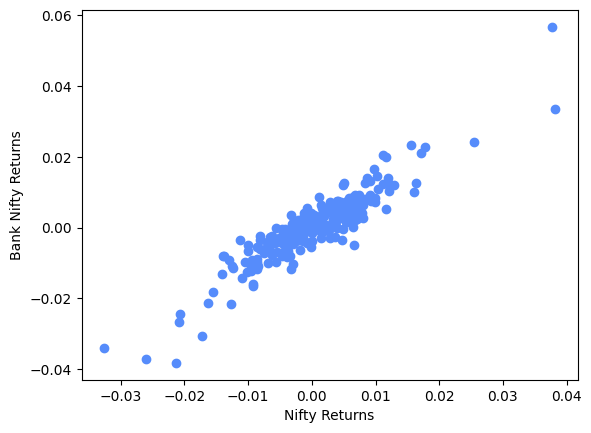

In [25]:
# -------------------------------
# 1. DEFINE TIME RANGE
# -------------------------------

# Today's date
end = dt.date.today()

# 1 year of data
start = end - dt.timedelta(365)


# -------------------------------
# 2. DOWNLOAD DATA
# -------------------------------

# Download NIFTY 50 and BANK NIFTY data
# ['Close'] selects only closing prices
df = yf.download(["^NSEI", "^NSEBANK"], start=start, end=end, auto_adjust=True)['Close']


# Rename columns for simplicity
df.rename(columns={'^NSEBANK': 'bank', '^NSEI': 'nse'}, inplace=True)


# -------------------------------
# 3. CALCULATE RETURNS
# -------------------------------

# Percentage returns
returns = df.pct_change().dropna()

# Separate variables
x = returns['nse']   # independent variable
y = returns['bank']  # dependent variable


# -------------------------------
# 4. SCATTER PLOT
# -------------------------------

# Each point = one day
# X-axis → NIFTY return
# Y-axis → BANK NIFTY return
plt.scatter(x, y)

plt.xlabel('Nifty Returns')
plt.ylabel('Bank Nifty Returns')

plt.show()

Correlation = 0.9188793235731311


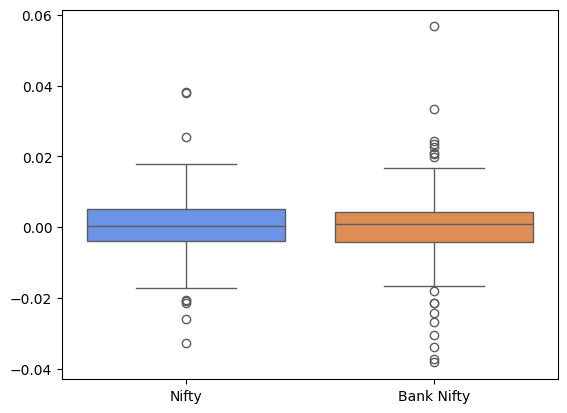

Outliers:
 Ticker          bank       nse
Date                          
2025-05-12  0.033354  0.038183
2026-02-03  0.024263  0.025476
2026-03-09 -0.030518 -0.017276
2026-03-19 -0.033891 -0.032621
2026-03-23 -0.037234 -0.026038
2026-03-30 -0.038245 -0.021394
2026-04-08  0.056674  0.037784


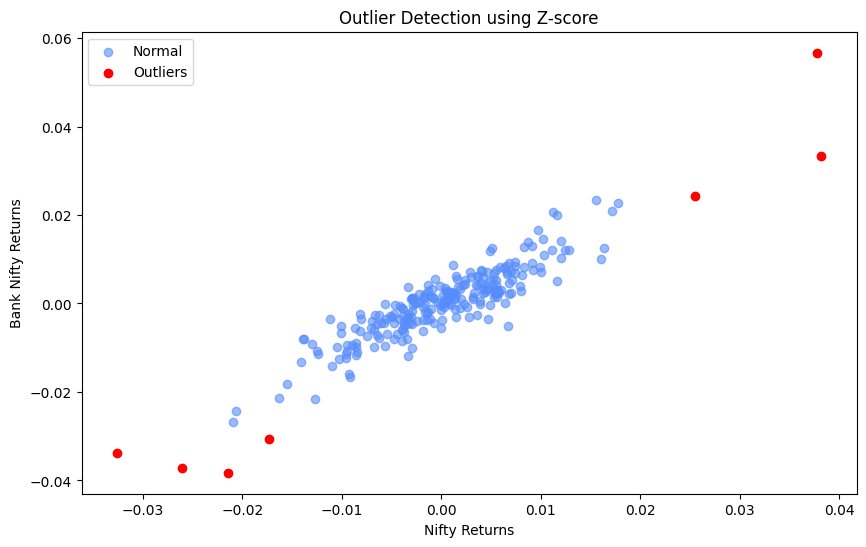

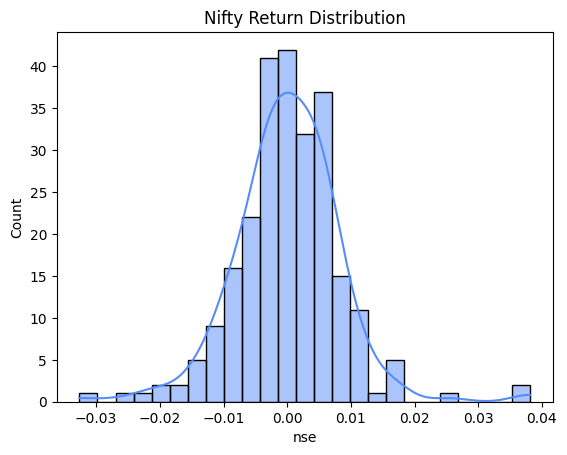

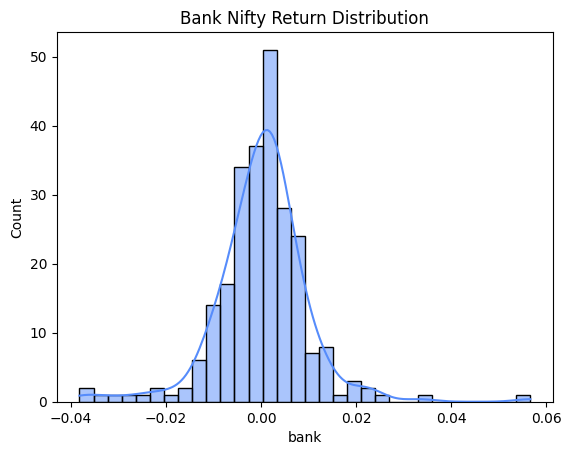

Date
2025-04-23   -0.012310
2025-04-24    0.000566
2025-04-25   -0.000504
2025-04-28    0.000934
2025-04-29   -0.001143
                ...   
2026-04-15   -0.005238
2026-04-16   -0.002340
2026-04-17    0.001445
2026-04-20   -0.000270
2026-04-21    0.004443
Length: 246, dtype: float64


In [26]:
# -------------------------------
# 1. CORRELATION
# -------------------------------

# Measures linear relationship between NIFTY and BANK NIFTY
corr = x.corr(y)
print("Correlation =", corr)


# -------------------------------
# 2. OUTLIER CHECK (BOXPLOT)
# -------------------------------

# Boxplot shows distribution + extreme values
sns.boxplot(data=[x, y])
plt.xticks([0, 1], ['Nifty', 'Bank Nifty'])
plt.show()


# -------------------------------
# 3. OUTLIER DETECTION (Z-SCORE)
# -------------------------------

from scipy.stats import zscore

# Convert to standardized values (mean=0, std=1)
z_x = pd.Series(zscore(x), index=x.index)
z_y = pd.Series(zscore(y), index=y.index)

# Outlier condition: beyond 3 standard deviations
outliers = (z_x.abs() > 3) | (z_y.abs() > 3)

# Print extreme observations
print("Outliers:\n", returns[outliers])


# Visualize outliers
plt.figure(figsize=(10,6))

# Normal points
plt.scatter(x[~outliers], y[~outliers], label='Normal', alpha=0.6)

# Outliers in red
plt.scatter(x[outliers], y[outliers], color='red', label='Outliers')

plt.xlabel('Nifty Returns')
plt.ylabel('Bank Nifty Returns')
plt.title('Outlier Detection using Z-score')
plt.legend()

plt.show()


# -------------------------------
# 4. DISTRIBUTION CHECK
# -------------------------------

# Histogram + KDE (density curve)
sns.histplot(x, kde=True)
plt.title("Nifty Return Distribution")
plt.show()

sns.histplot(y, kde=True)
plt.title("Bank Nifty Return Distribution")
plt.show()


# -------------------------------
# 5. REGRESSION MODEL
# -------------------------------

import statsmodels.api as sm

# Add constant (intercept = alpha)
x = sm.add_constant(x)

# Fit OLS regression: y = alpha + beta*x
model = sm.OLS(y, x).fit()

# Residuals = actual - predicted
residuals = model.resid

print(residuals)



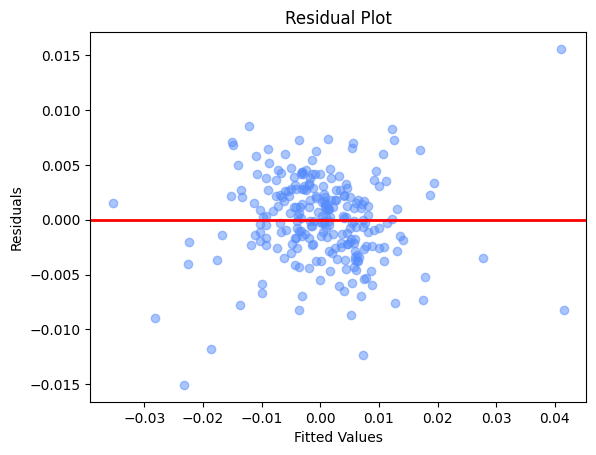

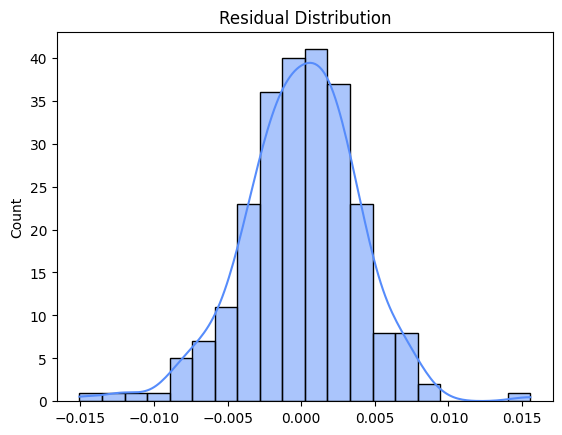

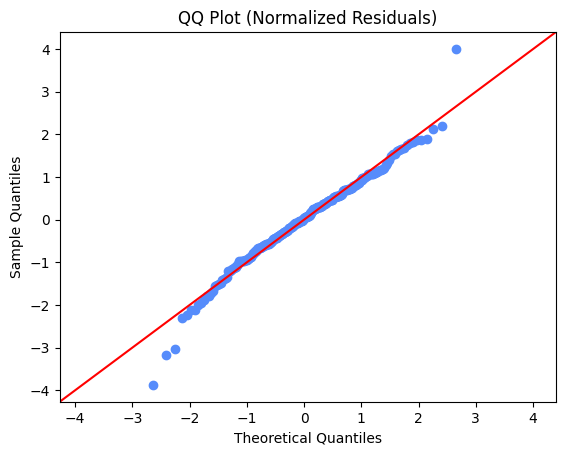

In [27]:

# 6. RESIDUAL DIAGNOSTICS
# -------------------------------

# Residual vs fitted (checks pattern)
plt.scatter(model.fittedvalues, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linewidth=2)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


# Residual distribution
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


# QQ plot (checks normality)
sm.qqplot(residuals, fit=True, line='45')
plt.title("QQ Plot (Normalized Residuals)")
plt.show()

In [28]:
# -------------------------------
# 7. MODEL SUMMARY
# -------------------------------

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   bank   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     1324.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          1.55e-100
Time:                        16:28:35   Log-Likelihood:                 1016.2
No. Observations:                 246   AIC:                            -2028.
Df Residuals:                     244   BIC:                            -2021.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.071e-05      0.000      0.244      0.8

In [29]:

# -------------------------------
# 8. INTERPRETATION
# -------------------------------

print("Dependent Variable → Bank Nifty Returns")
print("Independent Variable → Nifty Returns")

alpha = model.params.iloc[0]
print(f"Alpha: {alpha} → return when market = 0")

beta = model.params.iloc[1]
print(f"Beta: {beta} → sensitivity to market")

p_value = model.pvalues.iloc[1]
print(f"P-value: {p_value} → {'Significant' if p_value < 0.05 else 'Not significant'}")

t_stat = model.tvalues.iloc[1]
print(f"T-stat: {t_stat} → strength of relationship")

std_err = model.bse.iloc[1]
print(f"Standard Error: {std_err} → uncertainty in beta")

r2 = model.rsquared
print(f"R²: {r2} → explained variance")

adj_r2 = model.rsquared_adj
print(f"Adjusted R²: {adj_r2}")

f_stat = model.fvalue
print(f"F-statistic: {f_stat}")

f_pval = model.f_pvalue
print(f"F-test p-value: {f_pval}")

# Error metrics
mae = np.mean(np.abs(residuals))
print(f"MAE: {mae}")

rmse = np.sqrt(np.mean(residuals**2))
print(f"RMSE: {rmse}")


# -------------------------------
# 9. RESIDUAL PROPERTIES
# -------------------------------

from statsmodels.stats.stattools import durbin_watson

# Autocorrelation check
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw}")

# Shape of distribution
skew = residuals.skew()
print(f"Skewness: {skew}")

kurt = residuals.kurtosis()
print(f"Kurtosis: {kurt}")

# Normality test
from scipy.stats import jarque_bera
jb_stat, jb_p = jarque_bera(residuals)

print(f"Jarque-Bera p-value: {jb_p}")

Dependent Variable → Bank Nifty Returns
Independent Variable → Nifty Returns
Alpha: 6.0706626327671196e-05 → return when market = 0
Beta: 1.0864569239946622 → sensitivity to market
P-value: 1.5491107788567769e-100 → Significant
T-stat: 36.38009083521545 → strength of relationship
Standard Error: 0.02986405198700016 → uncertainty in beta
R²: 0.8443392112902155 → explained variance
Adjusted R²: 0.8437012572381262
F-statistic: 1323.511009178528
F-test p-value: 1.5491107788566827e-100
MAE: 0.0029771619586032904
RMSE: 0.003887686460465196
Durbin-Watson: 2.0533112485236793
Skewness: -0.2639684281495501
Kurtosis: 1.5883208337627996
Jarque-Bera p-value: 1.4580327486959844e-06
